<a href="https://colab.research.google.com/github/danhhuit/deep_learning_practice/blob/main/Labs02_Reduction_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## REGRESSION
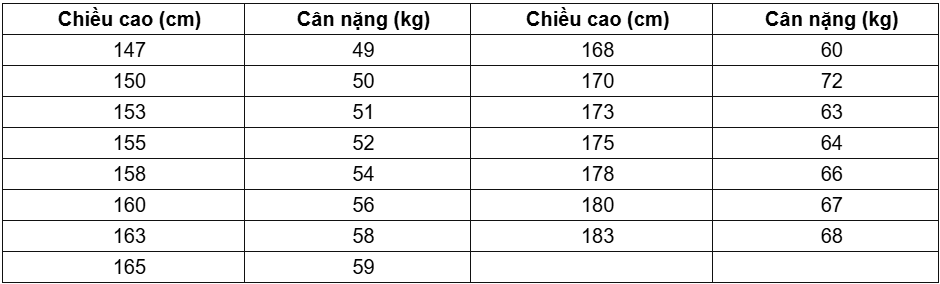

In [ ]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model

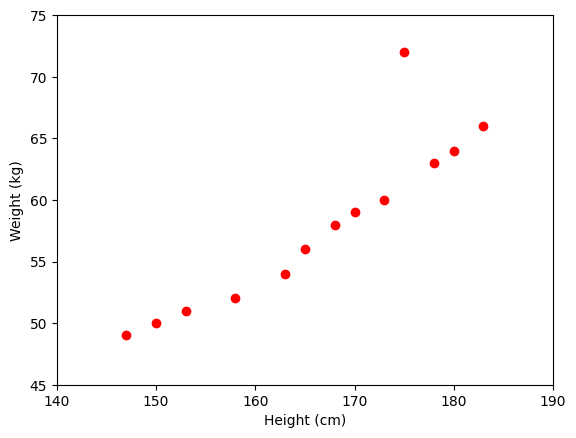

In [ ]:
# height (cm), weight (kg)
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
Y = np.array([[49, 50, 51, 52, 54, 56, 58, 59, 60, 72, 63, 64, 66]]).T
# visualize data
plt.plot(X, Y, 'ro')
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

w =  [[-31.03242177]
 [  0.53510008]]


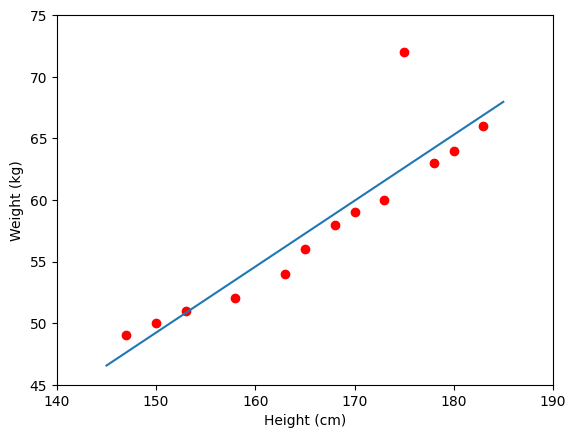

In [ ]:
# Building Xbar
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

# Calculating weights of the fitting line
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, Y)
w = np.dot(np.linalg.pinv(A), b)
print('w = ', w)

# Preparing the fititng line
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1*x0

# Drawing the fitting line
plt.plot(X.T, Y.T, 'ro')
plt.plot(x0, y0)
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

In [ ]:
y1 = w_1*155 + w_0
y2 = w_1*160 + w_0
print('Predict weight of person with height 155 cm: %.2f (kg), Predict weight of person with height 160 cm: %.2f (kg)' % (y1, y2))

Predict weight of person with height 155 cm: 51.91 (kg), Predict weight of person with height 160 cm: 54.58 (kg)


In [ ]:
regr = linear_model.LinearRegression(fit_intercept=False)
regr.fit(Xbar, Y)

# Compare two results
print('Solution found by scikit-learn  : ', regr.coef_)
print('Solution found by (5): ', w.T)

Solution found by scikit-learn  :  [[-31.03242176   0.53510008]]
Solution found by (5):  [[-31.03242177   0.53510008]]


## ANN (ARTIFICAL NEURAL NETWORK)

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf

import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, cross_validate

In [7]:
# pip install scikeras

In [11]:
fashion = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion.load_data()
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [16]:
X_train = train_images.reshape(60000, 784)
X_test = test_images.reshape(10000, 784)

minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes: ', len(np.unique(train_labels)))
print('Classes: ', np.unique(train_labels))


Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]


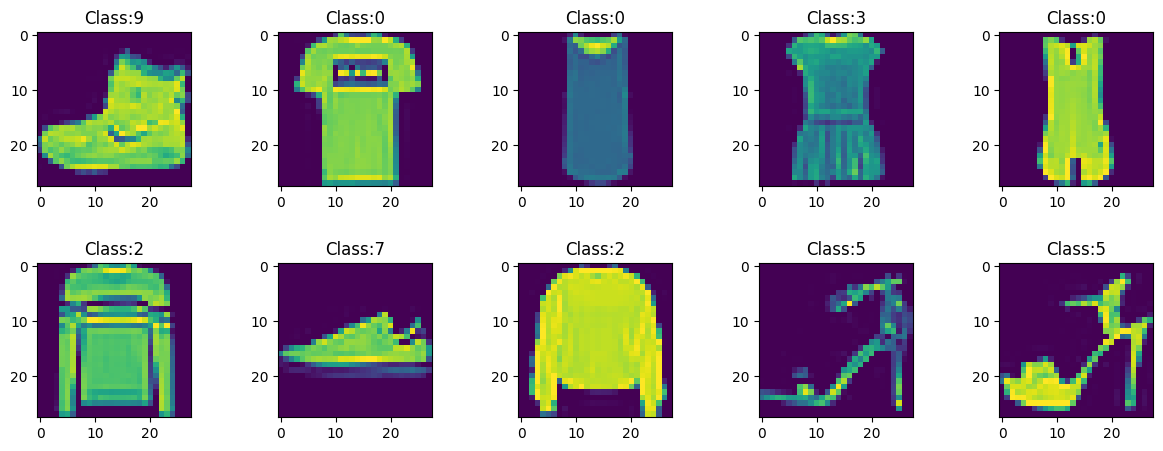

In [21]:
import matplotlib.pyplot as plt

# Data visualization
fig, axes = plt.subplots(nrows = 2, ncols = 5, figsize = (15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(train_images[i].reshape(28, 28))
  ax[i].title.set_text('Class:' + str(train_labels[i]))
plt.subplots_adjust(hspace = 0.5)
plt.show()

In [29]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Input # Import Input layer

fashion_model = Sequential([
    Input(shape=(X_train.shape[1],)), # Explicitly define input layer
    Dense(units = 256, activation = 'relu', kernel_initializer='uniform'),
    Dense(units=10, kernel_initializer='uniform', activation = 'softmax')
])
fashion_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
fashion_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model_fit = fashion_model.fit(X_train, train_labels, epochs = 20, verbose = 1, validation_split = 0.1)

Epoch 1/20


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense' is incompatible with the layer: expected axis -1 of input shape to have value 28, but received input with shape (None, 784)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 784), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>